# <center>Задача 7. Нейронные сети</center>
## <center>Классификация изображений цифр (MNIST)</center>

### Подготовка данных

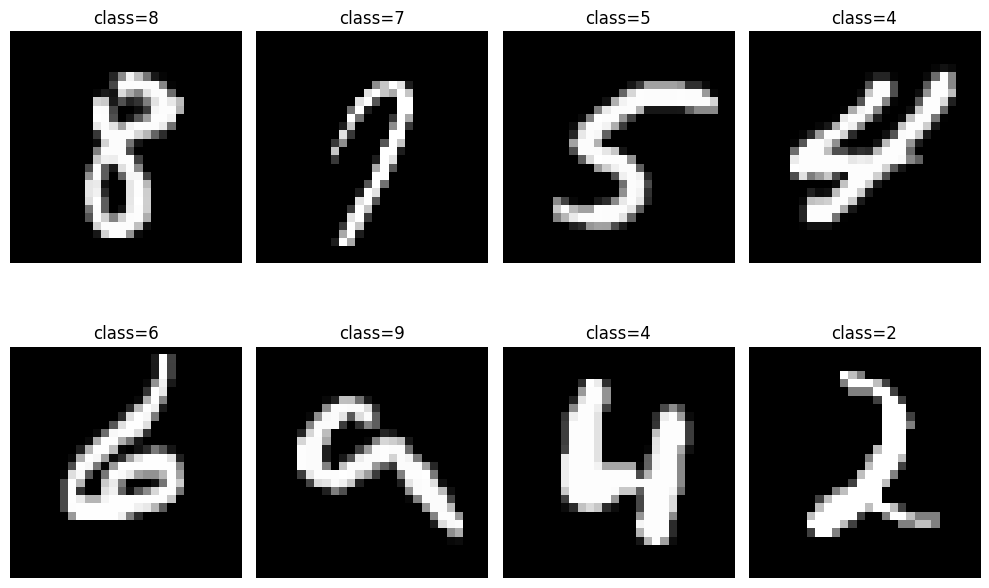

(54000, 784) (6000, 784) (10000, 784)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)

loaded = False

try:
    from tensorflow.keras.datasets import mnist
    (X_trainval, y_trainval), (X_test, y_test) = mnist.load_data()
    loaded = True
except Exception:
    try:
        from keras.datasets import mnist
        (X_trainval, y_trainval), (X_test, y_test) = mnist.load_data()
        loaded = True
    except Exception:
        pass

if not loaded:
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X_all = mnist.data.astype(np.float64).reshape(-1, 28, 28)
    y_all = mnist.target.astype(np.int64)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X_all, y_all, test_size=10000, random_state=42, stratify=y_all
    )

X_trainval = X_trainval.astype(np.float64)
X_test = X_test.astype(np.float64)

X_trainval = X_trainval.reshape(len(X_trainval), -1) / 255.0
X_test = X_test.reshape(len(X_test), -1) / 255.0
y_trainval = y_trainval.astype(np.int64)
y_test = y_test.astype(np.int64)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1, random_state=42, stratify=y_trainval
)

mean = X_train.mean(axis=0, keepdims=True)
std = X_train.std(axis=0, keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

fig, axes = plt.subplots(2, 4, figsize=(10, 7))
indices = np.random.default_rng(42).choice(len(X_trainval), size=8, replace=False)

for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X_trainval[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"class={y_trainval[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()
print(X_train.shape, X_val.shape, X_test.shape)

### Слои и модель

In [10]:

def batches(X, y, batch_size=64, shuffle=True):
    idx = np.arange(len(X))
    if shuffle:
        np.random.shuffle(idx)
    for i in range(0, len(X), batch_size):
        j = idx[i:i + batch_size]
        yield X[j], y[j]

class FullyConnectedLayer:
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2 / in_features)
        self.b = np.zeros(out_features)

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dY):
        self.dW = self.X.T @ dY
        self.db = dY.sum(axis=0)
        return dY @ self.W.T

    def params_and_grads(self):
        return [(self.W, self.dW), (self.b, self.db)]

class ReluLayer:
    def forward(self, X):
        self.X = X
        return np.maximum(X, 0)

    def backward(self, dY):
        return dY * (self.X > 0)

    def params_and_grads(self):
        return []

class BatchNormLayer:
    def __init__(self, dim, eps=1e-5, momentum=0.9):
        self.gamma = np.ones(dim)
        self.beta = np.zeros(dim)
        self.eps = eps
        self.momentum = momentum
        self.running_mean = np.zeros(dim)
        self.running_var = np.ones(dim)

    def forward(self, X, train=True):
        if train:
            self.X = X
            self.mean = X.mean(axis=0)
            self.var = X.var(axis=0)
            self.X_hat = (X - self.mean) / np.sqrt(self.var + self.eps)
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * self.mean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * self.var
            return self.gamma * self.X_hat + self.beta
        X_hat = (X - self.running_mean) / np.sqrt(self.running_var + self.eps)
        return self.gamma * X_hat + self.beta

    def backward(self, dY):
        n = dY.shape[0]
        self.dbeta = dY.sum(axis=0)
        self.dgamma = np.sum(dY * self.X_hat, axis=0)
        dX_hat = dY * self.gamma
        inv = 1 / np.sqrt(self.var + self.eps)
        dvar = np.sum(dX_hat * (self.X - self.mean) * (-0.5) * inv**3, axis=0)
        dmean = np.sum(dX_hat * (-inv), axis=0) + dvar * np.mean(-2 * (self.X - self.mean), axis=0)
        dX = dX_hat * inv + dvar * 2 * (self.X - self.mean) / n + dmean / n
        return dX

    def params_and_grads(self):
        return [(self.gamma, self.dgamma), (self.beta, self.dbeta)]

class CrossEntropyLoss:
    def forward(self, logits, y):
        s = logits - logits.max(axis=1, keepdims=True)
        e = np.exp(s)
        self.p = e / e.sum(axis=1, keepdims=True)
        self.y = y
        return -np.log(self.p[np.arange(len(y)), y] + 1e-12).mean()

    def backward(self):
        g = self.p.copy()
        g[np.arange(len(self.y)), self.y] -= 1
        g /= len(self.y)
        return g

class MLP:
    def __init__(self, input_dim, hidden=64, use_bn=False):
        self.layers = [FullyConnectedLayer(input_dim, hidden)]
        if use_bn:
            self.layers.append(BatchNormLayer(hidden))
        self.layers += [ReluLayer(), FullyConnectedLayer(hidden, 10)]

    def forward(self, X, train=True):
        out = X
        for layer in self.layers:
            if isinstance(layer, BatchNormLayer):
                out = layer.forward(out, train=train)
            else:
                out = layer.forward(out)
        return out

    def backward(self, grad):
        out = grad
        for layer in self.layers[::-1]:
            out = layer.backward(out)
        return out

    def params_and_grads(self):
        res = []
        for layer in self.layers:
            res.extend(layer.params_and_grads())
        return res

    def reg_loss(self, reg):
        s = 0.0
        for layer in self.layers:
            if isinstance(layer, FullyConnectedLayer):
                s += 0.5 * reg * np.sum(layer.W * layer.W)
        return s

    def add_reg_grads(self, reg):
        for layer in self.layers:
            if isinstance(layer, FullyConnectedLayer):
                layer.dW += reg * layer.W


### Оптимизаторы

In [11]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr

    def step(self, params_and_grads):
        for p, g in params_and_grads:
            p -= self.lr * g

class Momentum:
    def __init__(self, lr=0.01, mu=0.9):
        self.lr = lr
        self.mu = mu
        self.v = {}

    def step(self, params_and_grads):
        for p, g in params_and_grads:
            k = id(p)
            if k not in self.v:
                self.v[k] = np.zeros_like(p)
            self.v[k] = self.mu * self.v[k] - self.lr * g
            p += self.v[k]

class RMSprop:
    def __init__(self, lr=0.001, decay=0.9, eps=1e-8):
        self.lr = lr
        self.decay = decay
        self.eps = eps
        self.cache = {}

    def step(self, params_and_grads):
        for p, g in params_and_grads:
            k = id(p)
            if k not in self.cache:
                self.cache[k] = np.zeros_like(p)
            self.cache[k] = self.decay * self.cache[k] + (1 - self.decay) * (g * g)
            p -= self.lr * g / (np.sqrt(self.cache[k]) + self.eps)

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}
        self.v = {}
        self.t = 0

    def step(self, params_and_grads):
        self.t += 1
        for p, g in params_and_grads:
            k = id(p)
            if k not in self.m:
                self.m[k] = np.zeros_like(p)
                self.v[k] = np.zeros_like(p)
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * g
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (g * g)
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


### Обучение и вспомогательные функции

In [12]:
import csv
import copy

def accuracy(logits, y):
    return (logits.argmax(axis=1) == y).mean()

def evaluate(model, X, y, reg=1e-4):
    loss_fn = CrossEntropyLoss()
    logits = model.forward(X, train=False)
    loss = loss_fn.forward(logits, y) + model.reg_loss(reg)
    acc = accuracy(logits, y)
    return loss, acc

def capture_bn_state(model):
    state = []
    for layer in model.layers:
        if isinstance(layer, BatchNormLayer):
            state.append((layer.running_mean.copy(), layer.running_var.copy()))
    return state

def restore_bn_state(model, state):
    ptr = 0
    for layer in model.layers:
        if isinstance(layer, BatchNormLayer):
            layer.running_mean = state[ptr][0].copy()
            layer.running_var = state[ptr][1].copy()
            ptr += 1

def gradient_check_step(
    model,
    x,
    y,
    reg=1e-4,
    checks_per_param=1,
    max_tensors=None,
    seed=0,
    h=1e-5,
):
    """
    Быстрый gradient check:
    - маленький batch
    - несколько случайных координат на тензор
    - сохранение/восстановление BatchNorm running statistics
    """
    loss_fn = CrossEntropyLoss()
    bn_state = capture_bn_state(model)

    logits = model.forward(x, train=True)
    loss_fn.forward(logits, y)
    grad = loss_fn.backward()
    model.backward(grad)
    model.add_reg_grads(reg)

    errs = []
    rng = np.random.default_rng(seed)
    params = model.params_and_grads()
    if max_tensors is not None:
        params = params[:max_tensors]

    for p, g in params:
        if p.ndim == 0:
            idx_list = [()]
        else:
            n_checks = min(checks_per_param, max(1, p.size))
            idx_list = [tuple(rng.integers(0, s) for s in p.shape) for _ in range(n_checks)]

        for idx in idx_list:
            old = p[idx]

            p[idx] = old + h
            restore_bn_state(model, bn_state)
            l1 = loss_fn.forward(model.forward(x, train=True), y) + model.reg_loss(reg)

            p[idx] = old - h
            restore_bn_state(model, bn_state)
            l2 = loss_fn.forward(model.forward(x, train=True), y) + model.reg_loss(reg)

            p[idx] = old
            restore_bn_state(model, bn_state)

            num = (l1 - l2) / (2 * h)
            ana = g[idx]
            err = abs(num - ana) / max(1e-8, abs(num) + abs(ana))
            errs.append(float(err))

    restore_bn_state(model, bn_state)
    return max(errs), float(np.mean(errs))

def clone_model(model):
    return copy.deepcopy(model)

def train_model(
    model,
    optimizer,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    batch_size=64,
    reg=1e-4,
    do_grad_check=True,
    grad_check_subset=4,
    grad_check_every=1,
    grad_check_checks_per_param=1,
    grad_check_max_tensors=None,
    epoch_log_path=None,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "grad_check_max_err": [],
        "grad_check_mean_err": [],
        "generalization_gap": [],
    }
    loss_fn = CrossEntropyLoss()

    best_val_loss = np.inf
    best_model = clone_model(model)

    writer = None
    log_file = None
    if epoch_log_path is not None:
        log_file = open(epoch_log_path, "w", newline="", encoding="utf-8")
        writer = csv.writer(log_file)
        writer.writerow([
            "epoch",
            "train_loss",
            "train_acc",
            "val_loss",
            "val_acc",
            "generalization_gap",
            "grad_check_max_err",
            "grad_check_mean_err",
            "best_so_far",
        ])

    try:
        for epoch in range(epochs):
            for xb, yb in batches(X_train, y_train, batch_size=batch_size, shuffle=True):
                logits = model.forward(xb, train=True)
                loss_fn.forward(logits, yb)
                grad = loss_fn.backward()
                model.backward(grad)
                model.add_reg_grads(reg)
                optimizer.step(model.params_and_grads())

            gc_max = None
            gc_mean = None
            if do_grad_check and (epoch % grad_check_every == 0):
                gc_max, gc_mean = gradient_check_step(
                    model,
                    X_train[:grad_check_subset],
                    y_train[:grad_check_subset],
                    reg=reg,
                    checks_per_param=grad_check_checks_per_param,
                    max_tensors=grad_check_max_tensors,
                    seed=epoch,
                )

            train_loss, train_acc = evaluate(model, X_train, y_train, reg=reg)
            val_loss, val_acc = evaluate(model, X_val, y_val, reg=reg)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)
            history["grad_check_max_err"].append(gc_max)
            history["grad_check_mean_err"].append(gc_mean)
            history["generalization_gap"].append(val_loss - train_loss)

            is_best = val_loss < best_val_loss
            if is_best:
                best_val_loss = val_loss
                best_model = clone_model(model)

            mark = "(best)" if is_best else ""
            print(
                f"epoch {epoch + 1:2d}/{epochs} | "
                f"yrain loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
                f"val loss: {val_loss:.4f}  acc: {val_acc:.4f} {mark}"
            )
            if gc_max is not None:
                status = "Gradients OK" if gc_max < 1e-4 else "Check gradients"
                print(f"  [Grad check] max_err={gc_max:.2e} mean_err={gc_mean:.2e} | {status}")

            if writer is not None:
                writer.writerow([
                    epoch + 1,
                    float(train_loss),
                    float(train_acc),
                    float(val_loss),
                    float(val_acc),
                    float(val_loss - train_loss),
                    gc_max,
                    gc_mean,
                    int(is_best),
                ])
    finally:
        if log_file is not None:
            log_file.close()

    model.layers = best_model.layers
    print(f"Restored best weights (val loss = {best_val_loss:.4f})")
    return history

def gradient_check():
    np.random.seed(0)
    model = MLP(input_dim=X_train.shape[1], hidden=8, use_bn=False)
    x = X_train[:4]
    y = y_train[:4]
    return gradient_check_step(
        model,
        x,
        y,
        reg=1e-4,
        checks_per_param=2,
        max_tensors=4,
        seed=0,
    )

def plot_training_diagnostics(history, title=""):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    axes[0, 0].plot(epochs, history["train_loss"], label="train")
    axes[0, 0].plot(epochs, history["val_loss"], label="val")
    axes[0, 0].set_title(f"Loss {title}")
    axes[0, 0].set_xlabel("epoch")
    axes[0, 0].set_ylabel("loss")
    axes[0, 0].grid(True)
    axes[0, 0].legend()

    axes[0, 1].plot(epochs, history["train_acc"], label="train")
    axes[0, 1].plot(epochs, history["val_acc"], label="val")
    axes[0, 1].set_title(f"Accuracy {title}")
    axes[0, 1].set_xlabel("epoch")
    axes[0, 1].set_ylabel("accuracy")
    axes[0, 1].grid(True)
    axes[0, 1].legend()

    axes[1, 0].plot(epochs, history["generalization_gap"], label="val_loss - train_loss")
    axes[1, 0].axhline(0.0, linestyle="--")
    axes[1, 0].set_title("Generalization gap")
    axes[1, 0].set_xlabel("epoch")
    axes[1, 0].set_ylabel("gap")
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    gc_epochs = [e for e, v in zip(epochs, history["grad_check_max_err"]) if v is not None]
    gc_max = [v for v in history["grad_check_max_err"] if v is not None]
    gc_mean = [v for v in history["grad_check_mean_err"] if v is not None]
    if gc_epochs:
        axes[1, 1].plot(gc_epochs, gc_max, marker="o", label="max rel error")
        axes[1, 1].plot(gc_epochs, gc_mean, marker="o", label="mean rel error")
        axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Gradient check error")
    axes[1, 1].set_xlabel("epoch")
    axes[1, 1].set_ylabel("relative error")
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

def plot_lr_search(lr_results):
    lrs = [row[0] for row in lr_results]
    best_val_loss = [row[1] for row in lr_results]
    best_val_acc = [row[2] for row in lr_results]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(lrs, best_val_loss, marker="o")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("learning rate")
    axes[0].set_ylabel("best val loss")
    axes[0].set_title("Learning rate vs best val loss")
    axes[0].grid(True)

    axes[1].plot(lrs, best_val_acc, marker="o")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("learning rate")
    axes[1].set_ylabel("best val accuracy")
    axes[1].set_title("Learning rate vs best val accuracy")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_optimizer_comparison(optimizer_results):
    names = [row[0] for row in optimizer_results]
    val_acc = [row[1] for row in optimizer_results]
    val_loss = [row[2] for row in optimizer_results]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(names, val_acc)
    axes[0].set_title("Final val accuracy by optimizer")
    axes[0].set_ylabel("accuracy")
    axes[0].grid(True, axis="y")

    axes[1].bar(names, val_loss)
    axes[1].set_title("Final val loss by optimizer")
    axes[1].set_ylabel("loss")
    axes[1].grid(True, axis="y")

    plt.tight_layout()
    plt.show()

def confusion_matrix_np(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def plot_confusion_matrix_and_errors(model, X, y, n_examples=12):
    logits = model.forward(X, train=False)
    pred = logits.argmax(axis=1)

    cm = confusion_matrix_np(y, pred, n_classes=10)
    plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion matrix")
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    wrong = np.where(pred != y)[0]
    if len(wrong) == 0:
        print("No misclassified examples on this split")
        return

    show_idx = wrong[:min(n_examples, len(wrong))]
    rows = int(np.ceil(len(show_idx) / 4))
    fig, axes = plt.subplots(rows, 4, figsize=(10, 2.5 * rows))
    axes = np.array(axes).reshape(-1)
    probs = np.exp(logits[show_idx] - logits[show_idx].max(axis=1, keepdims=True))
    probs = probs / probs.sum(axis=1, keepdims=True)

    for ax, idx, pr in zip(axes, show_idx, probs):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"t={y[idx]}, p={pred[idx]}, conf={pr[pred[idx]]:.2f}")
        ax.axis("off")

    for ax in axes[len(show_idx):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Проверка градиентов

In [13]:

max_err, mean_err = gradient_check()
print("max relative error:", max_err)
print("mean relative error:", mean_err)


max relative error: 1.978403877790836e-07
mean relative error: 2.478409640333932e-08


### Подбор learning rate

In [ ]:
np.random.seed(42)

lrs = [0.3, 0.1, 0.03, 0.01, 0.003]
lr_results = []

for lr in lrs:
    model = MLP(input_dim=X_train.shape[1], hidden=64, use_bn=True)
    optimizer = RMSprop(lr=lr)
    history = train_model(
        model, optimizer, X_train, y_train, X_val, y_val,
        epochs=12, batch_size=64, reg=1e-4,
        do_grad_check=True, grad_check_subset=4,
        grad_check_every=1, grad_check_checks_per_param=1, grad_check_max_tensors=4
    )
    lr_results.append((lr, min(history["val_loss"]), max(history["val_acc"])))

for row in lr_results:
    print(row)

best_lr = min(lr_results, key=lambda x: x[1])[0]
print("best lr:", best_lr)

plot_lr_search(lr_results)

### Оптимизаторы

epoch  1/10 | yrain loss: 0.1699  acc: 0.9548 | val loss: 0.2036  acc: 0.9527 (best)
  [Grad check] max_err=1.36e-08 mean_err=3.50e-09 | Gradients OK
epoch  2/10 | yrain loss: 0.1189  acc: 0.9723 | val loss: 0.1667  acc: 0.9615 (best)
  [Grad check] max_err=7.16e-07 mean_err=1.79e-07 | Gradients OK
epoch  3/10 | yrain loss: 0.1038  acc: 0.9767 | val loss: 0.1671  acc: 0.9650 
  [Grad check] max_err=5.74e-10 mean_err=2.21e-10 | Gradients OK
epoch  4/10 | yrain loss: 0.0903  acc: 0.9815 | val loss: 0.1530  acc: 0.9688 (best)
  [Grad check] max_err=2.15e-08 mean_err=6.16e-09 | Gradients OK
epoch  5/10 | yrain loss: 0.0780  acc: 0.9841 | val loss: 0.1547  acc: 0.9688 
  [Grad check] max_err=2.56e-09 mean_err=6.98e-10 | Gradients OK
epoch  6/10 | yrain loss: 0.0749  acc: 0.9857 | val loss: 0.1488  acc: 0.9712 (best)
  [Grad check] max_err=1.73e-09 mean_err=6.42e-10 | Gradients OK
epoch  7/10 | yrain loss: 0.0720  acc: 0.9875 | val loss: 0.1546  acc: 0.9697 
  [Grad check] max_err=4.19e-08 m

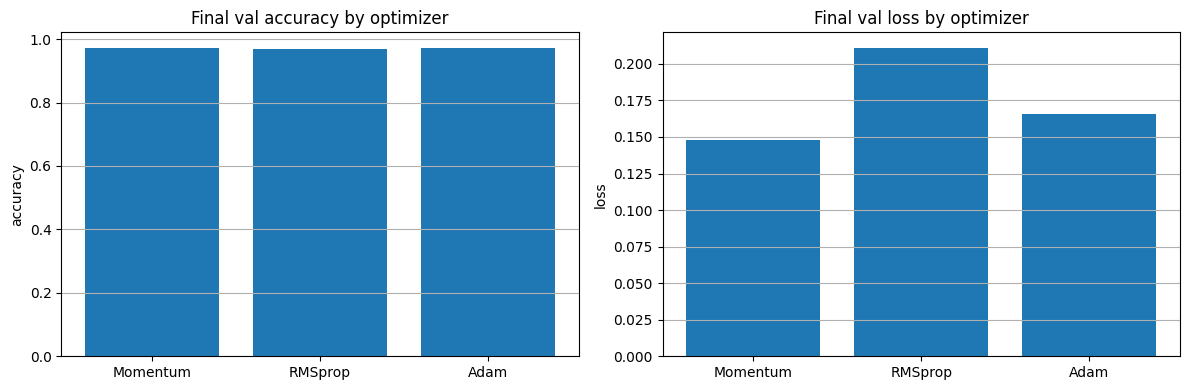

In [ ]:
np.random.seed(42)

optimizer_results = []

settings = [
    ("Momentum", Momentum(lr=0.03)),
    ("RMSprop", RMSprop(lr=0.01)),
    ("Adam", Adam(lr=0.003)),
]

for name, optimizer in settings:
    model = MLP(input_dim=X_train.shape[1], hidden=64, use_bn=True)
    history = train_model(
        model, optimizer, X_train, y_train, X_val, y_val,
        epochs=10, batch_size=64, reg=1e-4,
        do_grad_check=True, grad_check_subset=4,
        grad_check_every=1, grad_check_checks_per_param=1, grad_check_max_tensors=4
    )
    optimizer_results.append((name, history["val_acc"][-1], history["val_loss"][-1]))

for row in optimizer_results:
    print(row)

plot_optimizer_comparison(optimizer_results)

### Финальная модель

In [ ]:
np.random.seed(42)

model = MLP(input_dim=X_train.shape[1], hidden=64, use_bn=True)
optimizer = RMSprop(lr=best_lr)
history = train_model(
    model,
    optimizer,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=30,
    batch_size=64,
    reg=1e-4,
    do_grad_check=True,
    grad_check_subset=4,
    grad_check_every=1,
    grad_check_checks_per_param=1,
    grad_check_max_tensors=4,
    epoch_log_path="training_epoch_log.csv",
)

plot_training_diagnostics(history, title="(final model)")

test_loss, test_acc = evaluate(model, X_test, y_test, reg=1e-4)
print("test loss:", test_loss)
print("test accuracy:", test_acc)
print("logs saved to training_epoch_log.csv")

plot_confusion_matrix_and_errors(model, X_test, y_test)

epoch  1/30 | yrain loss: 0.1483  acc: 0.9612 | val loss: 0.1734  acc: 0.9560 (best)
  [Grad check] max_err=8.00e-09 mean_err=2.87e-09 | Gradients OK
epoch  2/30 | yrain loss: 0.1141  acc: 0.9745 | val loss: 0.1480  acc: 0.9658 (best)
  [Grad check] max_err=7.92e-07 mean_err=1.99e-07 | Gradients OK
epoch  3/30 | yrain loss: 0.1008  acc: 0.9804 | val loss: 0.1429  acc: 0.9713 (best)
  [Grad check] max_err=2.98e-08 mean_err=7.75e-09 | Gradients OK
epoch  4/30 | yrain loss: 0.0969  acc: 0.9816 | val loss: 0.1491  acc: 0.9688 
  [Grad check] max_err=1.10e-07 mean_err=3.62e-08 | Gradients OK
epoch  5/30 | yrain loss: 0.0910  acc: 0.9844 | val loss: 0.1466  acc: 0.9723 
  [Grad check] max_err=8.46e-08 mean_err=2.29e-08 | Gradients OK
epoch  6/30 | yrain loss: 0.0905  acc: 0.9846 | val loss: 0.1458  acc: 0.9722 
  [Grad check] max_err=5.62e-09 mean_err=1.57e-09 | Gradients OK
epoch  7/30 | yrain loss: 0.0885  acc: 0.9866 | val loss: 0.1429  acc: 0.9753 (best)
  [Grad check] max_err=1.92e-10 m